In [2]:
import time
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import data_generator

In [14]:
def unpack_data(dataset):
        X = np.array([item[0] for item in dataset])
        y = np.array([item[1] for item in dataset])
        return X, y
def split_data(data):
        train_data = data[:200]
        test_data = data[200:]
        return train_data, test_data
def decision_plot(X_test, y_test, y_pred, dataset_name, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Left: true data
    axes[0].scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_test,
        cmap=plt.cm.Set1,
        s=15,
        edgecolors='none'
    )
    axes[0].set_title("data")
    axes[0].set_xlabel("x1")
    axes[0].set_ylabel("x2")

    # Right: predicted labels
    axes[1].scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_pred,
        cmap=plt.cm.Set1,
        s=15,
        edgecolors='none'
    )
    axes[1].set_title(r"prediction $\hat{y}$")
    axes[1].set_xlabel("x1")
    axes[1].set_ylabel("x2")

    fig.suptitle(f"{dataset_name} — {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

 RUNNING PIPELINE FOR DATASET: CIRCLE 

--- Logistic Regression ---
Accuracy: 0.6170 | Runtime: 0.0021s


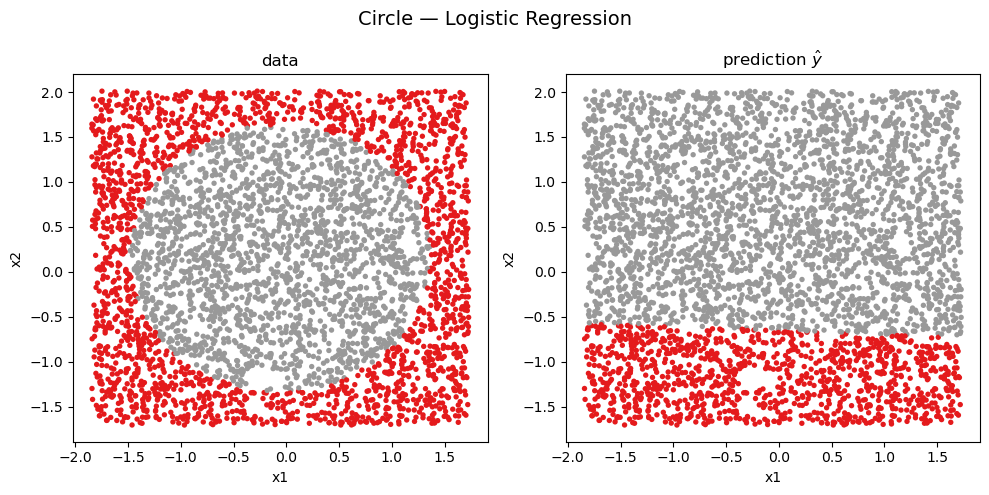


--- Random Forest ---
Accuracy: 0.9317 | Runtime: 0.1514s


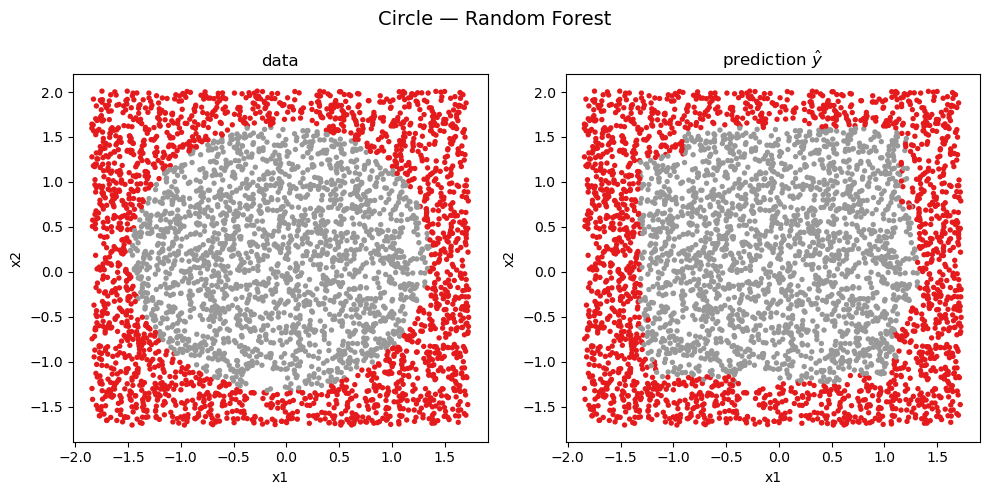


--- SVM ---
Accuracy: 0.9607 | Runtime: 0.0197s


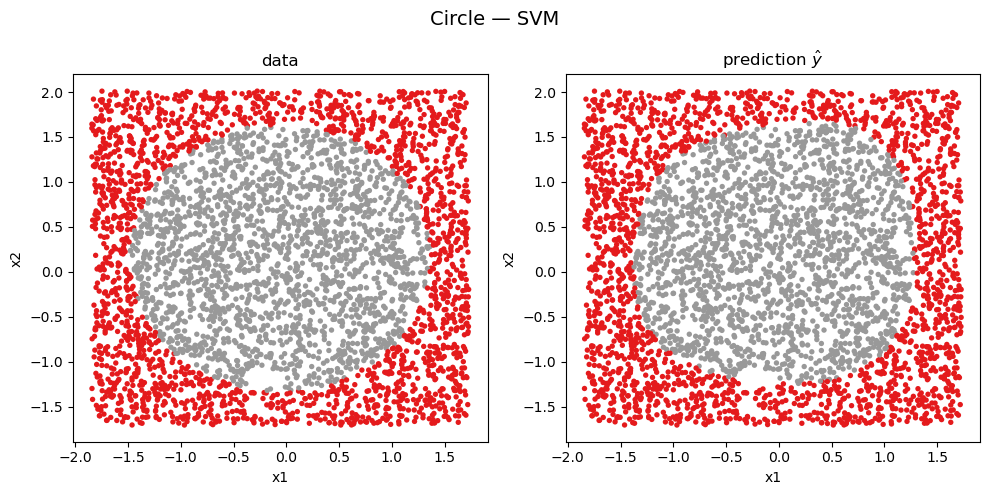


--- XGB ---
Accuracy: 0.9220 | Runtime: 0.1324s


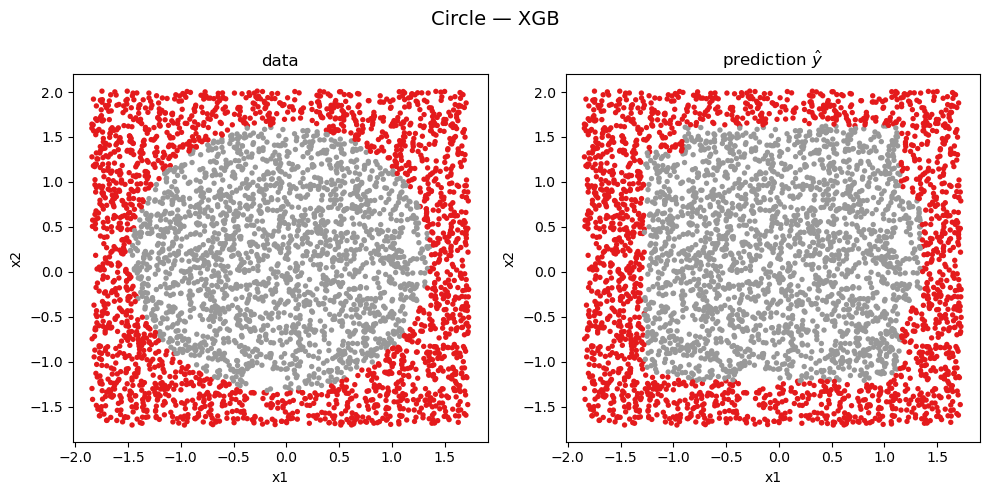

 RUNNING PIPELINE FOR DATASET: DIAMOND 

--- Logistic Regression ---
Accuracy: 0.5465 | Runtime: 0.0020s


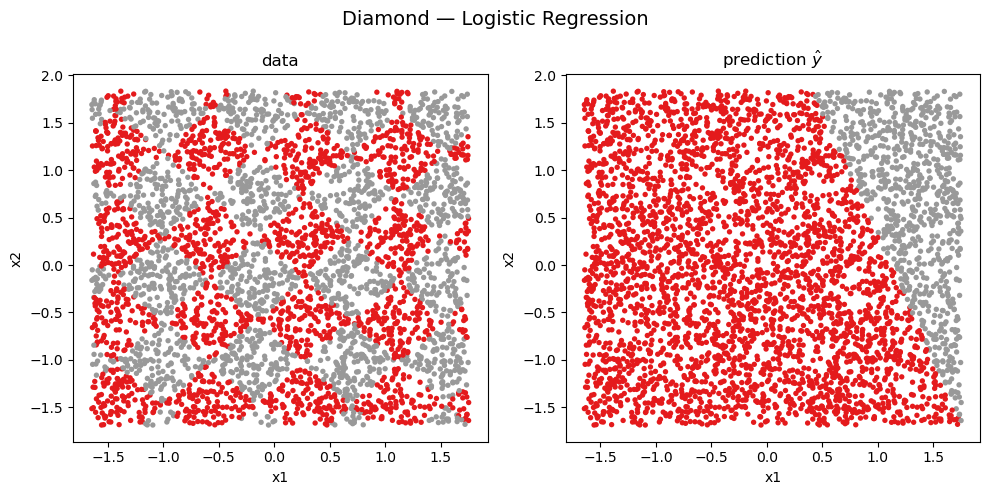


--- Random Forest ---
Accuracy: 0.7865 | Runtime: 0.1743s


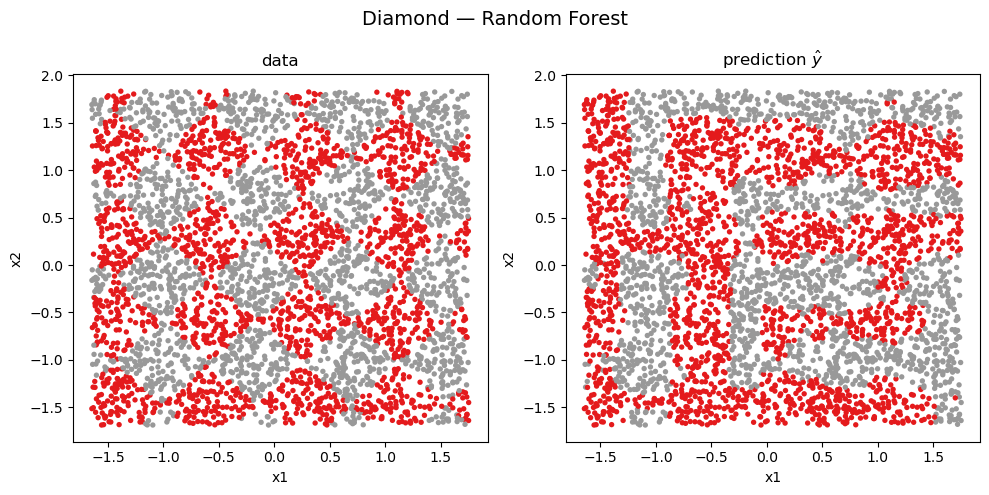


--- SVM ---
Accuracy: 0.5597 | Runtime: 0.0404s


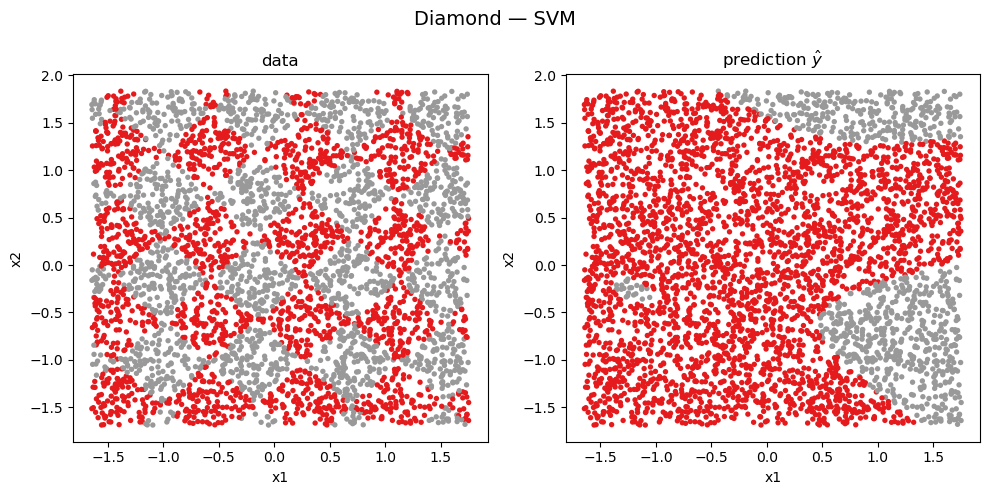


--- XGB ---
Accuracy: 0.8113 | Runtime: 0.1871s


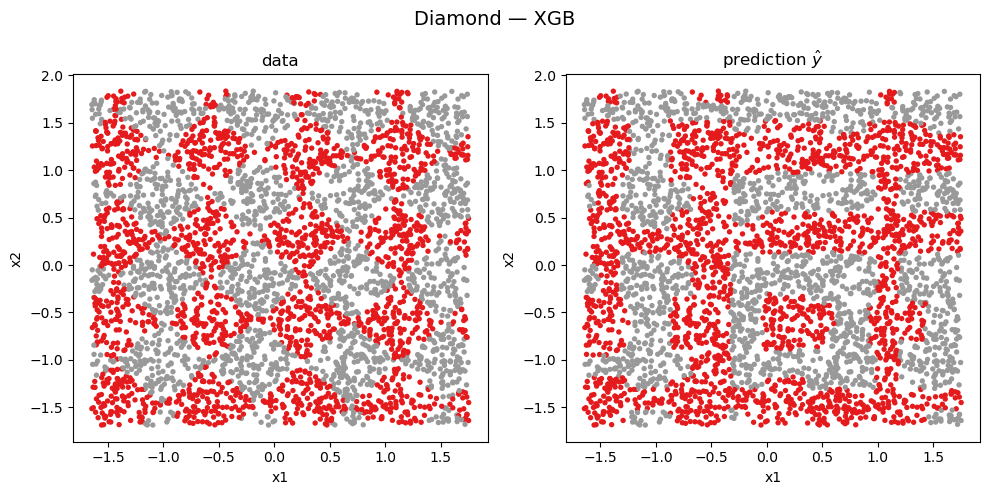

 RUNNING PIPELINE FOR DATASET: WAVY LINES 

--- Logistic Regression ---
Accuracy: 0.8552 | Runtime: 0.0039s


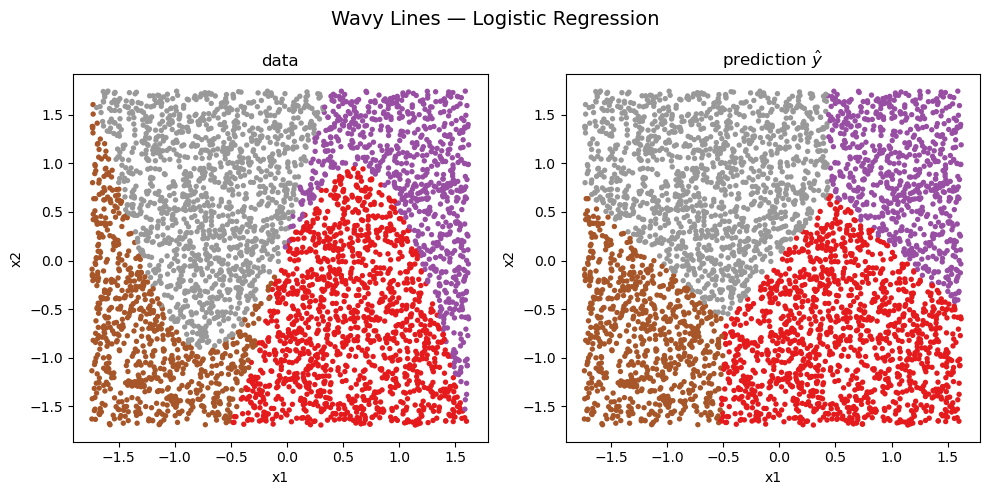


--- Random Forest ---
Accuracy: 0.9297 | Runtime: 0.1525s


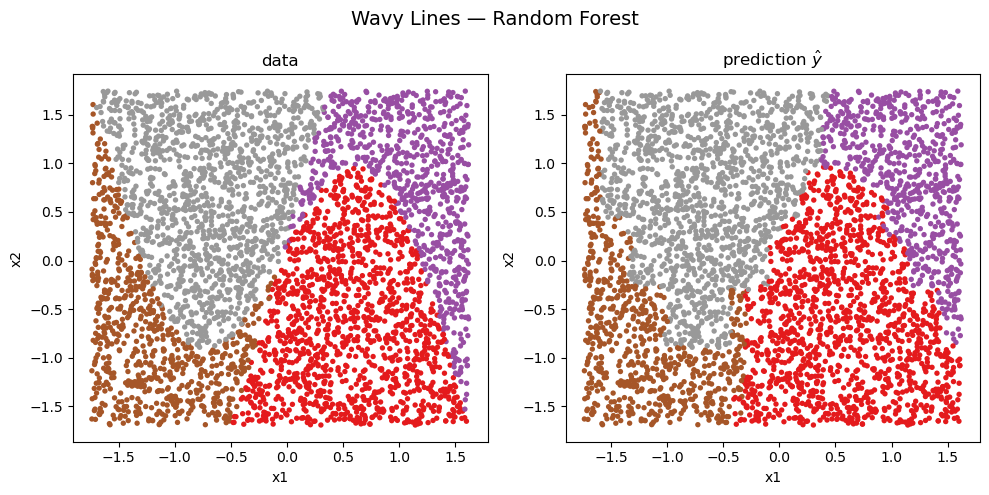


--- SVM ---
Accuracy: 0.9020 | Runtime: 0.0262s


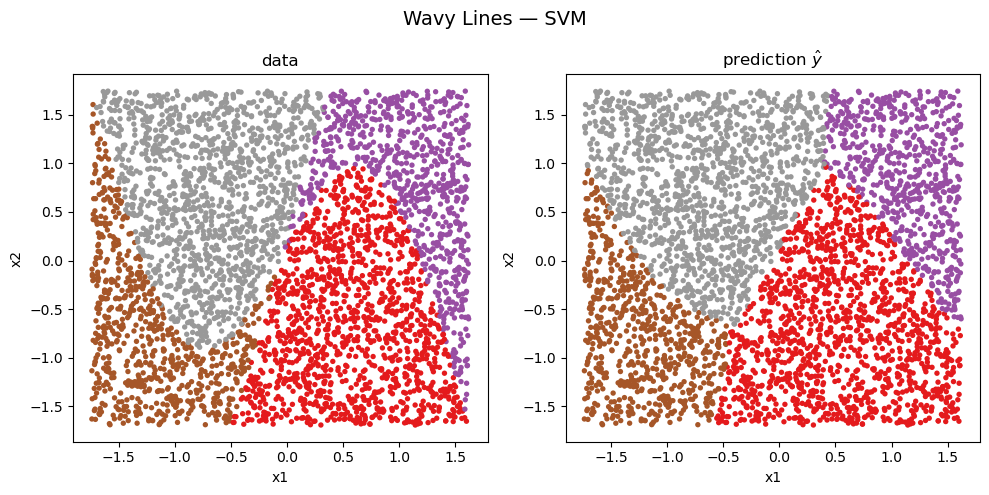


--- XGB ---
Accuracy: 0.9203 | Runtime: 0.4596s


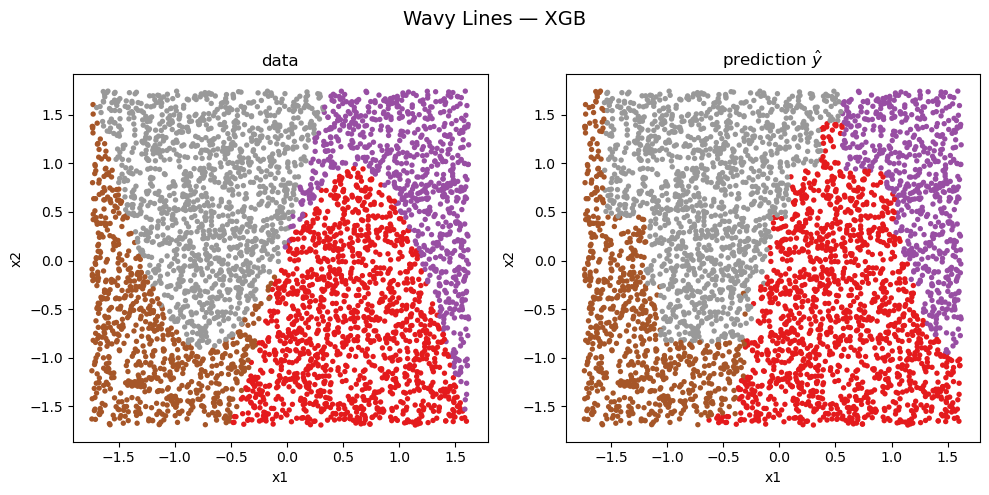

In [ ]:
# Map dataset names to their respective splitter and plotter functions
dataset_config = {
    'Circle': {'splitter': split_data, 'plotter': decision_plot},
    'Diamond': {'splitter': split_data, 'plotter': decision_plot},
    'Wavy Lines': {'splitter': split_data, 'plotter': decision_plot}
}

for dataset_name, config in dataset_config.items():
    print("=" * 60)
    print(f" RUNNING PIPELINE FOR DATASET: {dataset_name.upper()} ")
    print("=" * 60)
    
    # Generate and split
    data, _ = data_generator(dataset_name, samples=4200)
    X_train, y_train = unpack_data(data[:200])
    X_test, y_test = unpack_data(data[200:])
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Models
    models_to_train = {
        'Logistic Regression': LogisticRegression(),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf'),
        'XGB': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    }
    
    # Iterate through models to evaluate and plot
    for model_name, model in models_to_train.items():
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        elapsed_time = time.time() - start_time

        print(f"\n--- {model_name} ---")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | Runtime: {elapsed_time:.4f}s")

        # Plot decision boundary for this model
        decision_plot(X_test_scaled,y_test,y_pred,dataset_name,model_name)